In [1]:
import matplotlib.pyplot as plt
from datetime import datetime
date_str = datetime.now().strftime('%m%d')
import numpy as np

import brainpy as bp
import brainpy.math as bm

import tqdm

from network import DecisionMakingNet
from tools import Tool, load_plot_rates
from motor import collect_one_batch_trial_rates, merge_trial_rates, plot_motor_results_from_trial_rates

In [2]:
params = {
    'num_A': 888 // 2,
    'num_B': 888 // 2,
    'num_IA': 112 // 2,
    'num_IB': 112 // 2,
    'num_A_hb': 640 // 2,
    'num_B_hb': 640 // 2,
    'num_IA_hb': 360 // 2,
    'num_IB_hb': 360 // 2,
    'w_pos': 1.7,#1.7
    'g_ext2E_AMPA': 1.806,
    'g_ext2I_AMPA': 1.9,
    'g_E2E_AMPA': 0.05,
    'g_E2I_AMPA': 0.05,
    'g_E2E_NMDA': 0.2,
    'g_E2I_NMDA': 0.2,
    'g_I2E_GABAa': 2.0,
    'g_I2I_GABAa': 1.0,
    'w_inp2AB': 6, #7
    'w_inp2AB_rebound': 20,
    'w_rb_pos': 60,
    'w_rb_neg': 200,
    'scale': 5,
    'mu0': 20,
    'f': 0.15,
    'w_inp2hbAB': 40.,
    'hbi_weight': 0.5,
    'dTh2hb_weight': 0.3,
}

seqs = ['L']
# build model
bm.set_dt(0.1)
net = DecisionMakingNet(params=params, scale=params['scale'])
tool = Tool(seq=seqs)

# define input
def give_input():
    i = bp.share['i']
    net.Inp_A.freqs[0] = IA_freqs[i]
    net.Inp_B.freqs[0] = IB_freqs[i]
    
mu0 = params['mu0']
coherence = 100.
IA_freqs = tool.generate_freqs(R=mu0 + mu0 / 100. * coherence, L=mu0 - mu0 / 100. * coherence)
IB_freqs = tool.generate_freqs(R=mu0 - mu0 / 100. * coherence, L=mu0 + mu0 / 100. * coherence)


# simulation
monlist = [ 'Inp_A.spike', 'Inp_B.spike', 'A.spike', 'B.spike', 'IA.spike', 'IB.spike',
            'IA_rebound.spike', 'IB_rebound.spike', 'hb_A.spike', 'hb_B.spike', 'hb_IA.spike', 'hb_IB.spike']
runner = bp.DSRunner(net, inputs=give_input, monitors=monlist)
runner.run(tool.total_period)

# plot layer 1 2 and 3 activities
load_plot_rates(['Inp_A', 'Inp_B'], tool=tool, batch_num=26)
load_plot_rates(['A', 'B'], tool=tool, batch_num=26)
load_plot_rates(['hb_A', 'hb_B'], tool=tool, batch_num=26)

/opt/miniconda3/envs/motor_network/lib/python3.11/site-packages/jax/_src/ops/scatter.py:108: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=int32 to dtype=uint32 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(
/opt/miniconda3/envs/motor_network/lib/python3.11/site-packages/brainpy/mixin.py:476: UserWarning: Please use ".sum_current_inputs()" instead. ".sum_inputs()" will be removed.
  warnings.warn('Please use ".sum_current_inputs()" instead. ".sum_inputs()" will be removed.', UserWarning)


  0%|          | 0/350000 [00:00<?, ?it/s]

Saved: ../figures/20260209_Inp_A_Inp_B_full.pdf
Saved: ../figures/20260209_Inp_A_Inp_B_half.pdf
Saved: ../figures/20260209_A_B_full.pdf
Saved: ../figures/20260209_A_B_half.pdf
Saved: ../figures/20260209_hb_A_hb_B_full.pdf
Saved: ../figures/20260209_hb_A_hb_B_half.pdf



[Pairwise stats | Fig2] ../figures/motor_merged0 | final cumsum | Welch + Holm
  RR vs LR: t=-29.1, p=1.06e-96, p_holm=1.06e-96, **** (n=243,253)
  RR vs RL: t=-75.3, p=3.25e-225, p_holm=9.74e-225, **** (n=243,246)
  RR vs LL: t=-91, p=7.85e-308, p_holm=4.71e-307, **** (n=243,272)
  LR vs RL: t=-71.5, p=2.55e-263, p_holm=1.02e-262, **** (n=253,246)
  LR vs LL: t=-87.6, p=3.44e-282, p_holm=1.72e-281, **** (n=253,272)
  RL vs LL: t=-34, p=3.16e-126, p_holm=6.32e-126, **** (n=246,272)
[Saved] ../figures/motor_merged0_2trial_Fig2_final_pairwise_welch_holm.csv

[Pairwise stats | Fig3] ../figures/motor_merged0 | last1000ms Δcumsum | Welch + Holm
  RR vs LR: t=2.61, p=0.00925, p_holm=0.0555, ns (n=243,253)
  RR vs RL: t=2.47, p=0.0137, p_holm=0.0684, ns (n=243,246)
  RR vs LL: t=0.928, p=0.354, p_holm=0.708, ns (n=243,272)
  LR vs RL: t=-0.0691, p=0.945, p_holm=0.945, ns (n=253,246)
  LR vs LL: t=-1.73, p=0.0835, p_holm=0.334, ns (n=253,272)
  RL vs LL: t=-1.62, p=0.106, p_holm=0.334, ns (n=

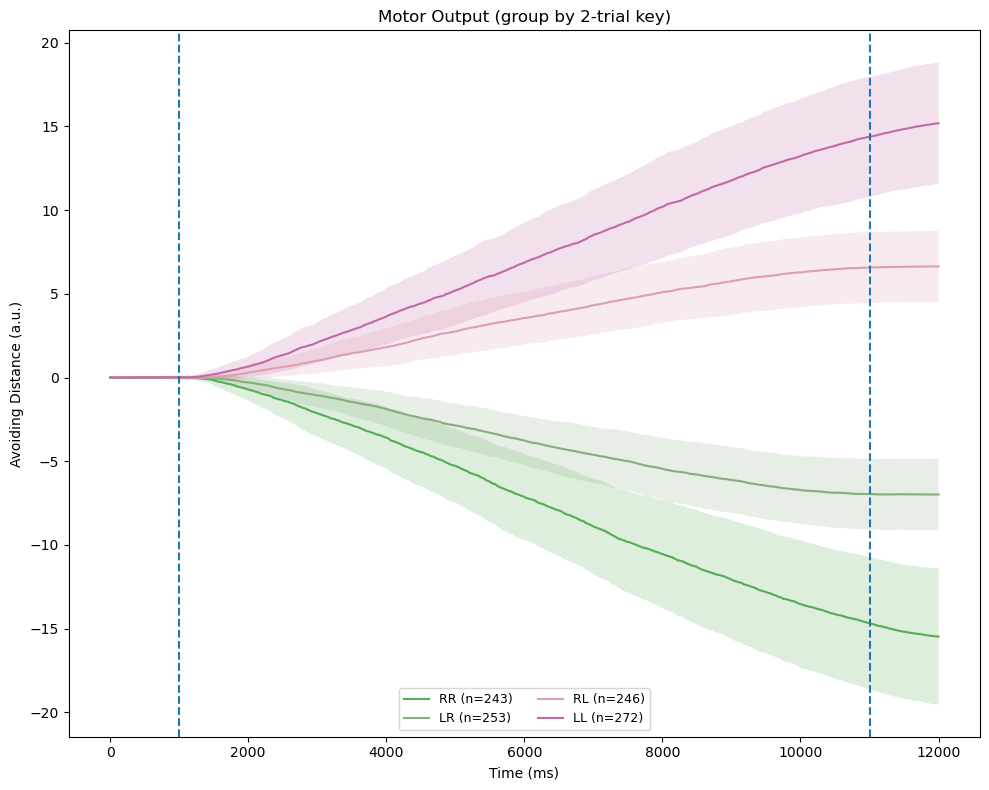

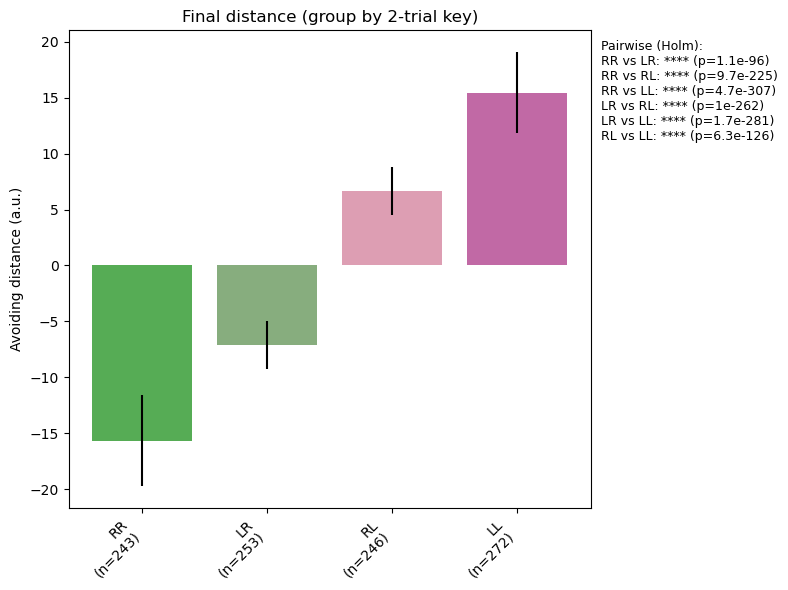

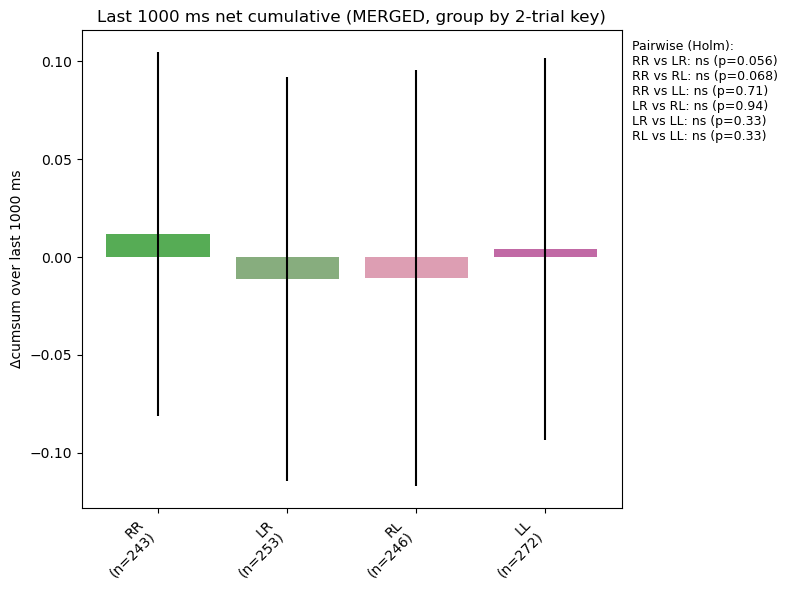

In [3]:
# plot motor output over multiple batches
for test_batch in range(1):
    batch_num = 26
    # 2-trial history
    trial_rates_all = []
    for i in range(batch_num):
        data_i = np.load(f'../results/rates_260126_batch{i}.npz', allow_pickle=True)
        ts, one_trial, tr = collect_one_batch_trial_rates(
            data_i, runner, tool,
            n_trials_in_key=2,
            output_mode="noise",   # 或 "signal+noise"
            params=None
        )
        trial_rates_all.append(tr)

    merged = merge_trial_rates(trial_rates_all)
    plot_motor_results_from_trial_rates(
        ts, one_trial, merged, tool,
        n_trials_in_key=2,
        max_plot_ms=12000,
        prefix=f"../figures/motor_merged{test_batch}"
    )

In [4]:
# load saved data and perform PCA + sliding window analysis for DTH
from sklearn.decomposition import PCA

# -----------------------
# parameters
date_str = datetime.now().strftime('%m%d')

dt = float(bm.get_dt())  # get simulation time step
pre_stimulus_period = tool.pre_stimulus_period
stimulus_period = tool.stimulus_period
delay_period = tool.delay_period

unique_conds = ['RR', 'LR', 'RL', 'LL']
drop_first_trials = 2  # <<< drop the first two trials of each batch/dataset

def process_group_rates(group_rates, seqs):
    """
    Process group_rates data:
      - Concatenate group_rates['A'] and group_rates['B'] along axis=1,
      - Reshape according to the number of trials to (num_trials, num_neurons, time_length)

    Assumptions:
      - After concatenating group_rates['A'] and group_rates['B'] along axis=1,
        data.shape[1] is approximately (2 * num_trials * time_length)
      - num_neurons = data.shape[0] * 2  (following your original code logic)
    """
    data = np.concatenate([group_rates['A'], group_rates['B']], axis=1)
    num_trials = len(seqs)
    num_neurons = data.shape[0] * 2
    time_length = data.shape[1] // num_trials // 2

    data = data.reshape(num_neurons, num_trials, time_length).transpose(1, 0, 2)
    return data, seqs, num_neurons, time_length


# -----------------------
# Load multiple batches and drop the first two trials of each batch
datas = []
seqs_list = []
conditions_list = []

num_neurons_ref = None
time_length_ref = None

for idx in range(26):
    npz = np.load(f'../results/rates_260126_batch{idx}.npz', allow_pickle=True)
    group_rates = npz['group_rates'].item()
    seqs = npz['sequences']

    data, seqs, num_neurons, time_length = process_group_rates(group_rates, seqs)

    # Skip batches with too few trials
    if len(seqs) <= drop_first_trials:
        continue

    # Record reference for consistency
    if num_neurons_ref is None:
        num_neurons_ref = num_neurons
        time_length_ref = time_length
    else:
        assert num_neurons == num_neurons_ref, f"Number of neurons inconsistent: batch{idx}"
        assert time_length == time_length_ref, f"Time length inconsistent: batch{idx}"

    # --- Drop the first two trials of each dataset ---
    data = data[drop_first_trials:]   # (num_trials-2, num_neurons, time_length)
    seqs = seqs[drop_first_trials:]   # (num_trials-2,)

    datas.append(data)
    seqs_list.append(seqs)

    # --- Condition list: for sliding window (concatenation of adjacent trials) ---
    # Each sample in the sliding window corresponds to (t-1, t), so the condition length = len(seqs)-1
    conditions = [seqs[i - 1] + seqs[i] for i in range(1, len(seqs))]
    conditions_list.append(conditions)

# Concatenate data along the trial dimension
combined_data = np.concatenate(datas, axis=0)  # (total_trials, num_neurons, time_length)
combined_seqs = np.concatenate(seqs_list, axis=0)
total_num_trials = combined_data.shape[0]

num_neurons = num_neurons_ref
time_length = time_length_ref

print("Total trials after dropping first 2 trials per batch:", total_num_trials)
print("num_neurons:", num_neurons, "time_length:", time_length)

# -----------------------
# PCA: reshape combined_data to (total_trials * time_length, num_neurons)
reshaped_data = combined_data.transpose(0, 2, 1).reshape(-1, num_neurons)

pca = PCA(n_components=3)
pca_result = pca.fit_transform(reshaped_data)
print("Explained variance ratio for the top 3 PCA components:", pca.explained_variance_ratio_)

# Reshape back to (total_trials, time_length, 3)
pca_data = pca_result.reshape(total_num_trials, time_length, -1)

# -----------------------
# Build sliding window: concatenate (trial[t-1], trial[t]) within each dataset
sliding_window_data_list = []
dataset_trial_counts = [len(seqs) for seqs in seqs_list]  # Note: trial counts after dropping first two trials

start = 0
for count in dataset_trial_counts:
    pca_data_ds = pca_data[start:start + count]  # (count, time_length, 3)
    sliding_window_ds = np.concatenate((pca_data_ds[:-1], pca_data_ds[1:]), axis=1)  # (count-1, 2*time_length, 3)
    sliding_window_data_list.append(sliding_window_ds)
    start += count

sliding_window_data = np.concatenate(sliding_window_data_list, axis=0)

# Combine conditions for sliding window (length must equal the number of sliding_window_data trials)
combined_conditions_for_sliding = []
for conds in conditions_list:
    combined_conditions_for_sliding.extend(conds)

assert len(combined_conditions_for_sliding) == sliding_window_data.shape[0], \
    f"Condition length ({len(combined_conditions_for_sliding)}) does not match sliding_window_data count ({sliding_window_data.shape[0]})"

# -----------------------
# Filter indices based on conditions
condition_indices = {cond: [] for cond in unique_conds}
for i, cond in enumerate(combined_conditions_for_sliding):
    if cond in unique_conds:
        condition_indices[cond].append(i)

# Calculate average trajectory for each condition    
avg_trajectories = {}
for cond in unique_conds:
    indices = condition_indices[cond]
    if len(indices) > 0:
        avg_trajectories[cond] = sliding_window_data[indices].mean(axis=0)  # (2*time_length, 3)

print({k: (len(v), avg_trajectories[k].shape if k in avg_trajectories else None)
       for k, v in condition_indices.items()})


Total trials after dropping first 2 trials per batch: 1014
num_neurons: 888 time_length: 350
Explained variance ratio for the top 3 PCA components: [9.47510190e-01 7.42384043e-03 5.72365863e-05]
{'RR': (238, (700, 3)), 'LR': (250, (700, 3)), 'RL': (244, (700, 3)), 'LL': (256, (700, 3))}


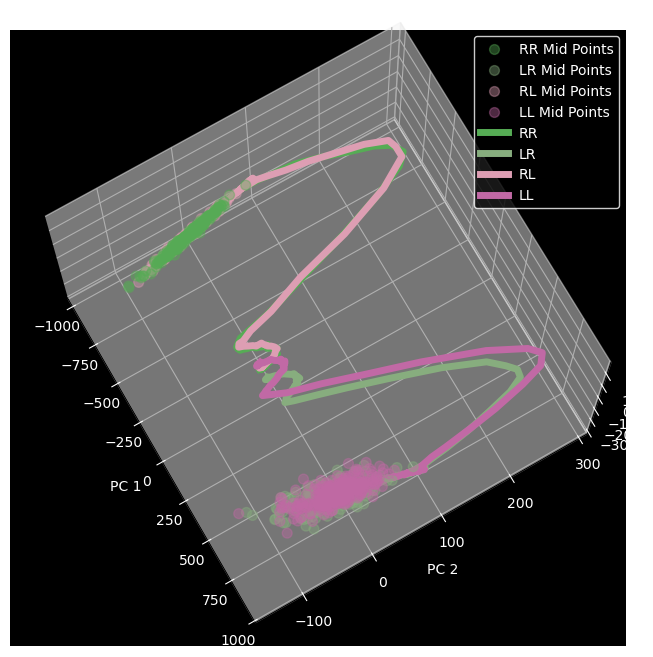

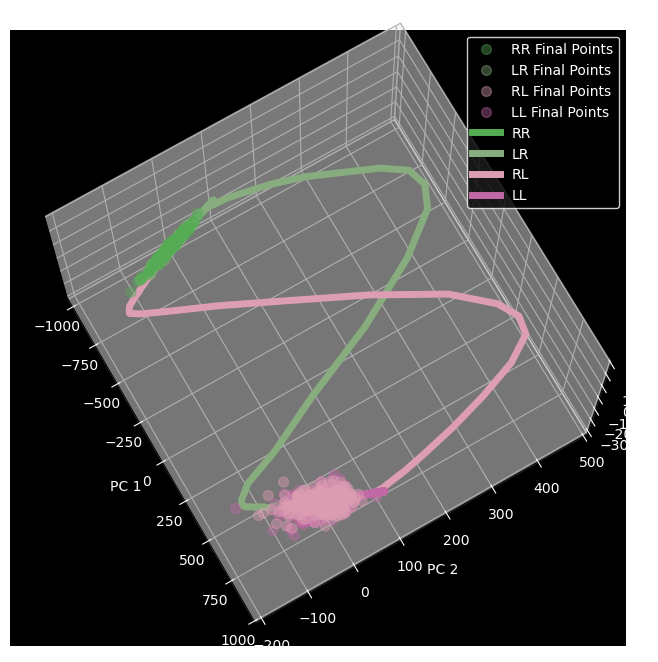

In [5]:
# PCA plotting - trial trajectories (3D)

# Color mapping
colors = {
    'RR': '#56ac55',
    'LR': '#87ad7e',
    'RL': '#dd9eb3',
    'LL': '#c169a5'
}

# Create two figures: first half and second half of average trajectories
fig1 = plt.figure(figsize=(12, 8))
ax1 = fig1.add_subplot(111, projection='3d')
ax1.set_title("First Half of Average Trajectories", color='white')
ax1.set_xlabel('PC 1', color='white')
ax1.set_ylabel('PC 2', color='white')
ax1.set_zlabel('PC 3', color='white')
ax1.view_init(elev=30, azim=-60)
ax1.set_facecolor('black')  # set background to black
ax1.xaxis.label.set_color('white')  # set axis label color
ax1.yaxis.label.set_color('white')
ax1.zaxis.label.set_color('white')
ax1.tick_params(colors='white')  # set tick color

fig2 = plt.figure(figsize=(12, 8))
ax2 = fig2.add_subplot(111, projection='3d')
ax2.set_title("Second Half of Average Trajectories", color='white')
ax2.set_xlabel('PC 1', color='white')
ax2.set_ylabel('PC 2', color='white')
ax2.set_zlabel('PC 3', color='white')
ax2.view_init(elev=30, azim=-60)
ax2.set_facecolor('black')  # set background to black
ax2.xaxis.label.set_color('white')  # set axis label color
ax2.yaxis.label.set_color('white')
ax2.zaxis.label.set_color('white')
ax2.tick_params(colors='white')  # set tick color

# Add final points of all trials to the first two plots
for cond in unique_conds:
    idxs = condition_indices[cond]
    final_points = sliding_window_data[idxs, -1, :]  # final point of each trial
    mid_point = sliding_window_data[idxs, sliding_window_data.shape[1]//2, :]  # middle point of each trial
    # Add scatter points for the first half (with reduced opacity)
    ax1.scatter(mid_point[:, 0], mid_point[:, 1], mid_point[:, 2],
                color=colors[cond], alpha=0.4, s=50, label=f'{cond} Mid Points')
    # Add scatter points for the second half (with reduced opacity)
    ax2.scatter(final_points[:, 0], final_points[:, 1], final_points[:, 2],
                color=colors[cond], alpha=0.4, s=50, label=f'{cond} Final Points')


# Plot average trajectories (split into first half and second half)
for cond, traj in avg_trajectories.items():
    L = len(traj)
    half = L // 2
    # First half
    ax1.plot(traj[:half, 0], traj[:half, 1], traj[:half, 2], color=colors[cond], linewidth=5, label=cond)

    # Second half
    ax2.plot(traj[half:, 0], traj[half:, 1], traj[half:, 2], color=colors[cond], linewidth=5, label=cond)




# Set legends
handles1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(handles1, labels1, loc='best', facecolor='black', edgecolor='white', labelcolor='white')
# ax1.view_init(elev=75, azim=-90)
ax1.view_init(elev=75, azim=-30)

handles2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(handles2, labels2, loc='best', facecolor='black', edgecolor='white', labelcolor='white')
# ax2.view_init(elev=75, azim=-90)
ax2.view_init(elev=75, azim=-30)

# save the figure
fig1.savefig(f'../figures/{date_str}_DTH First Half of Average Trajectories.pdf', dpi=300, transparent=True)
fig2.savefig(f'../figures/{date_str}_DTH Second Half of Average Trajectories.pdf', dpi=300, transparent=True)

plt.show()

In [6]:
#  load saved data and process PCA + sliding window analysis for HB
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# -----------------------
# parameters

dt = float(bm.get_dt())  # get time step
pre_stimulus_period = tool.pre_stimulus_period
stimulus_period = tool.stimulus_period
delay_period = tool.delay_period

unique_conds = ['RR', 'LL','LR', 'RL']
drop_first_trials = 2  # <<< drop the first two trials of each batch/dataset

def process_group_rates(group_rates, seqs):
    """
    Process group_rates data:
      - Concatenate group_rates['A'] and group_rates['B'] along axis=1, 
      - Reshape according to the number of trials to (num_trials, num_neurons, time_length)

    Assumptions:
      - After concatenating group_rates['A'] and group_rates['B'] along axis=1,
        data.shape[1] is approximately (2 * num_trials * time_length)
      - num_neurons = data.shape[0] * 2  (following your original code logic)
    """
    data = np.concatenate([group_rates['hb_A'], group_rates['hb_B']], axis=1)
    num_trials = len(seqs)
    num_neurons = data.shape[0] * 2
    time_length = data.shape[1] // num_trials // 2

    data = data.reshape(num_neurons, num_trials, time_length).transpose(1, 0, 2)
    return data, seqs, num_neurons, time_length


# -----------------------
# Load multiple batches and drop the first two trials in each batch
datas = []
seqs_list = []
conditions_list = []

num_neurons_ref = None
time_length_ref = None

for idx in range(26):
    npz = np.load(f'../results/rates_260126_batch{idx}.npz', allow_pickle=True)
    group_rates = npz['group_rates'].item()
    seqs = npz['sequences']

    data, seqs, num_neurons, time_length = process_group_rates(group_rates, seqs)

    # Skip batches with too few trials
    if len(seqs) <= drop_first_trials:
        continue

    # Record consistency reference
    if num_neurons_ref is None:
        num_neurons_ref = num_neurons
        time_length_ref = time_length
    else:
        assert num_neurons == num_neurons_ref, f"Number of neurons inconsistent: batch{idx}"
        assert time_length == time_length_ref, f"Time length inconsistent: batch{idx}"

    # --- Drop the first two trials of each dataset ---
    data = data[drop_first_trials:]   # (num_trials-2, num_neurons, time_length)
    seqs = seqs[drop_first_trials:]   # (num_trials-2,)

    datas.append(data)
    seqs_list.append(seqs)

    # --- Condition list: for sliding window (concatenation of adjacent trials) ---
    # Each sample in the sliding window corresponds to (t-1, t), so the condition length = len(seqs)-1
    conditions = [seqs[i - 1] + seqs[i] for i in range(1, len(seqs))]
    conditions_list.append(conditions)

# Concatenate data along the trial dimension
combined_data = np.concatenate(datas, axis=0)  # (total_trials, num_neurons, time_length)
combined_seqs = np.concatenate(seqs_list, axis=0)
total_num_trials = combined_data.shape[0]

num_neurons = num_neurons_ref
time_length = time_length_ref

print("Total trials after dropping first 2 trials per batch:", total_num_trials)
print("num_neurons:", num_neurons, "time_length:", time_length)

# -----------------------
# PCA: reshape combined_data to (total_trials * time_length, num_neurons)
reshaped_data = combined_data.transpose(0, 2, 1).reshape(-1, num_neurons)

pca = PCA(n_components=3)
pca_result = pca.fit_transform(reshaped_data)
print("Explained variance ratio for the top 3 PCA components:", pca.explained_variance_ratio_)

# Reshape back to (total_trials, time_length, 3)
pca_data = pca_result.reshape(total_num_trials, time_length, -1)

# -----------------------
# Construct sliding window: concatenate (trial[t-1], trial[t]) within each dataset
sliding_window_data_list = []
dataset_trial_counts = [len(seqs) for seqs in seqs_list]  # Note: number of trials after dropping the first two trials

start = 0
for count in dataset_trial_counts:
    pca_data_ds = pca_data[start:start + count]  # (count, time_length, 3)
    sliding_window_ds = np.concatenate((pca_data_ds[:-1], pca_data_ds[1:]), axis=1)  # (count-1, 2*time_length, 3)
    sliding_window_data_list.append(sliding_window_ds)
    start += count

sliding_window_data = np.concatenate(sliding_window_data_list, axis=0)

# Concatenate conditions for sliding window (length must match the number of trials in sliding_window_data)
combined_conditions_for_sliding = []
for conds in conditions_list:
    combined_conditions_for_sliding.extend(conds)

assert len(combined_conditions_for_sliding) == sliding_window_data.shape[0], \
    f"Condition length ({len(combined_conditions_for_sliding)}) does not match sliding_window_data count ({sliding_window_data.shape[0]})"

# -----------------------
# Filter indices based on conditions
condition_indices = {cond: [] for cond in unique_conds}
for i, cond in enumerate(combined_conditions_for_sliding):
    if cond in unique_conds:
        condition_indices[cond].append(i)

# Calculate average trajectory for each condition
avg_trajectories = {}
for cond in unique_conds:
    indices = condition_indices[cond]
    if len(indices) > 0:
        avg_trajectories[cond] = sliding_window_data[indices].mean(axis=0)  # (2*time_length, 3)

print({k: (len(v), avg_trajectories[k].shape if k in avg_trajectories else None)
       for k, v in condition_indices.items()})


Total trials after dropping first 2 trials per batch: 1014
num_neurons: 640 time_length: 350
Explained variance ratio for the top 3 PCA components: [4.42872935e-01 3.88639230e-01 3.00955766e-04]
{'RR': (238, (700, 3)), 'LL': (256, (700, 3)), 'LR': (250, (700, 3)), 'RL': (244, (700, 3))}


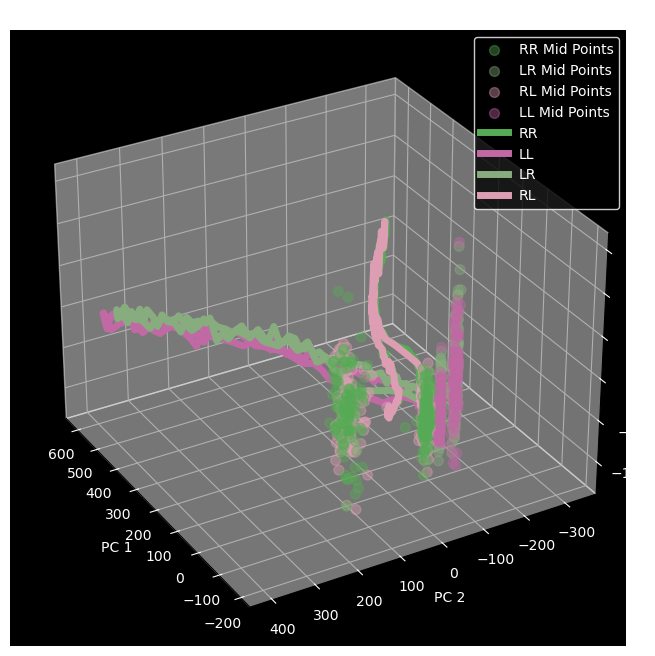

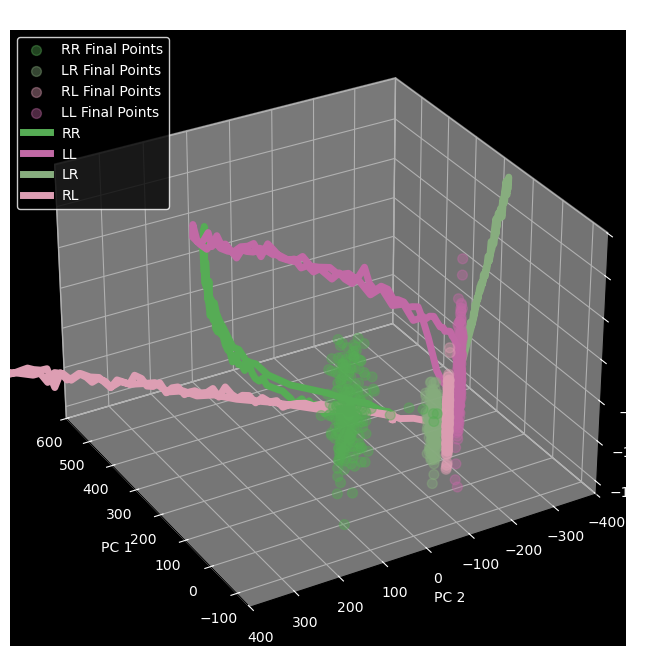

In [7]:
# PCA plotting - average trajectories split into first and second half

# Color mapping
colors = {
    'RR': '#56ac55',
    'LR': '#87ad7e',
    'RL': '#dd9eb3',
    'LL': '#c169a5'
}

# Create two figures: first half and second half of average trajectories
fig1 = plt.figure(figsize=(12, 8))
ax1 = fig1.add_subplot(111, projection='3d')
ax1.set_title("First Half of Average Trajectories", color='white')
ax1.set_xlabel('PC 1', color='white')
ax1.set_ylabel('PC 2', color='white')
ax1.set_zlabel('PC 3', color='white')
ax1.view_init(elev=30, azim=-60)
ax1.set_facecolor('black')  # set background to black
ax1.xaxis.label.set_color('white')  # set axis label color
ax1.yaxis.label.set_color('white')
ax1.zaxis.label.set_color('white')
ax1.tick_params(colors='white')  # set tick color
fig2 = plt.figure(figsize=(12, 8))
ax2 = fig2.add_subplot(111, projection='3d')
ax2.set_title("Second Half of Average Trajectories", color='white')
ax2.set_xlabel('PC 1', color='white')
ax2.set_ylabel('PC 2', color='white')
ax2.set_zlabel('PC 3', color='white')
ax2.view_init(elev=30, azim=-60)
ax2.set_facecolor('black')  # set background to black
ax2.xaxis.label.set_color('white')  # set axis label color
ax2.yaxis.label.set_color('white')
ax2.zaxis.label.set_color('white')
ax2.tick_params(colors='white')  # set tick color

# Add final points of all trials to the first two plots
unique_conds = ['RR', 'LR', 'RL', 'LL']
for cond in unique_conds:
    idxs = condition_indices[cond]
    final_points = sliding_window_data[idxs, -1, :]  # final point of each trial
    mid_point = sliding_window_data[idxs, sliding_window_data.shape[1]//2, :]  # middle point of each trial
    # Add scatter points for the first half (with reduced opacity)
    ax1.scatter(mid_point[:, 0], mid_point[:, 1], mid_point[:, 2],
                color=colors[cond], alpha=0.4, s=50, label=f'{cond} Mid Points')
    # Add scatter points for the second half (with reduced opacity)
    ax2.scatter(final_points[:, 0], final_points[:, 1], final_points[:, 2],
                color=colors[cond], alpha=0.4, s=50, label=f'{cond} Final Points')
    ax2.set_xlim3d([-150,600])
    ax2.set_ylim3d([-400,400])
    # ax2.set_zlim3d([-100,100])

# Plot average trajectories (split into first half and second half)
for cond, traj in avg_trajectories.items():
    L = len(traj)
    half = L // 2
    # first half
    ax1.plot(traj[:half, 0], traj[:half, 1], traj[:half, 2], color=colors[cond], linewidth=5, label=cond)

    # second half
    ax2.plot(traj[half:, 0], traj[half:, 1], traj[half:, 2], color=colors[cond], linewidth=5, label=cond)




# Set legends
handles1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(handles1, labels1, loc='best', facecolor='black', edgecolor='white', labelcolor='white')
# ax1.view_init(elev=75, azim=-90)
ax1.view_init(elev=30, azim=150)

handles2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(handles2, labels2, loc='best', facecolor='black', edgecolor='white', labelcolor='white')
# ax2.view_init(elev=75, azim=-90)
ax2.view_init(elev=30, azim=150)

# save the figure
fig1.savefig(f'../figures/{date_str}_HB First Half of Average Trajectories.pdf', dpi=300, transparent=True)
fig2.savefig(f'../figures/{date_str}_HB Second Half of Average Trajectories.pdf', dpi=300, transparent=True)

plt.show()
